In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [2]:
#connect mysql database

engine = create_engine(
    "mysql+pymysql://root:@localhost:3309/ecommerce_analytics1"
)

print("Database Connected Successfully!")

Database Connected Successfully!


In [3]:
#Total custumers

query = """
SELECT COUNT(DISTINCT customer_unique_id) AS total_customers
FROM customers;
"""

total_customers = pd.read_sql(query, engine)

total_customers

,total_customers
0,96096


In [4]:
print(f"Total Customers: {total_customers.iloc[0,0]:,}")

Total Customers: 96,096


In [7]:
# custmer by state

query = """
SELECT customer_state,
       COUNT(*) AS total_customers
FROM customers
GROUP BY customer_state
ORDER BY total_customers DESC;
"""

state_customers = pd.read_sql(query, engine)

state_customers.head()

,customer_state,total_customers
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045


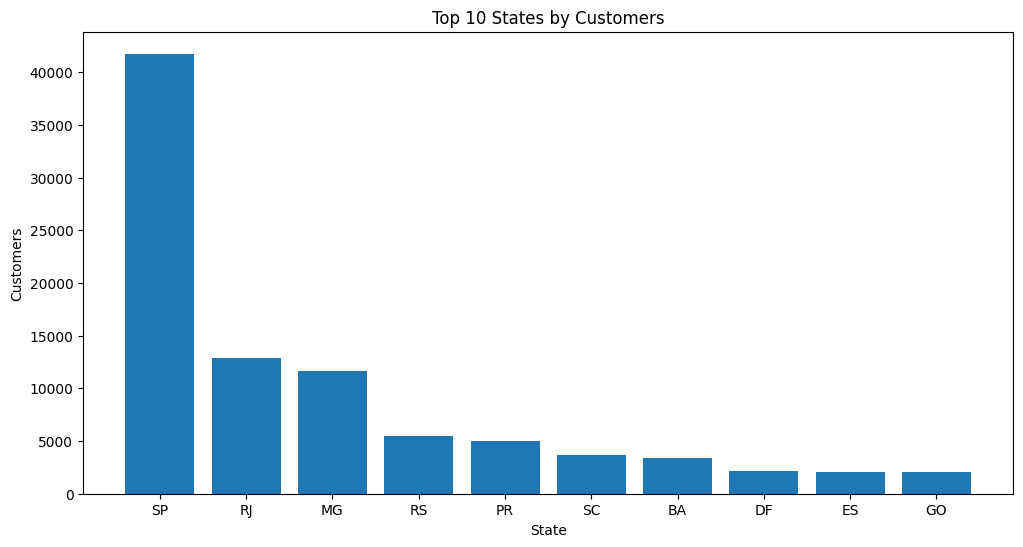

In [9]:
# Visualization 

plt.figure(figsize=(12,6))

plt.bar(
    state_customers['customer_state'][:10],
    state_customers['total_customers'][:10]
)

plt.title("Top 10 States by Customers")
plt.xlabel("State")
plt.ylabel("Customers")

plt.show()

In [10]:
# Top customer cities

query = """
SELECT customer_city,
       COUNT(*) AS total_customers
FROM customers
GROUP BY customer_city
ORDER BY total_customers DESC
LIMIT 10;
"""

top_cities = pd.read_sql(query, engine)

top_cities

,customer_city,total_customers
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521
5,campinas,1444
6,porto alegre,1379
7,salvador,1245
8,guarulhos,1189
9,sao bernardo do campo,938


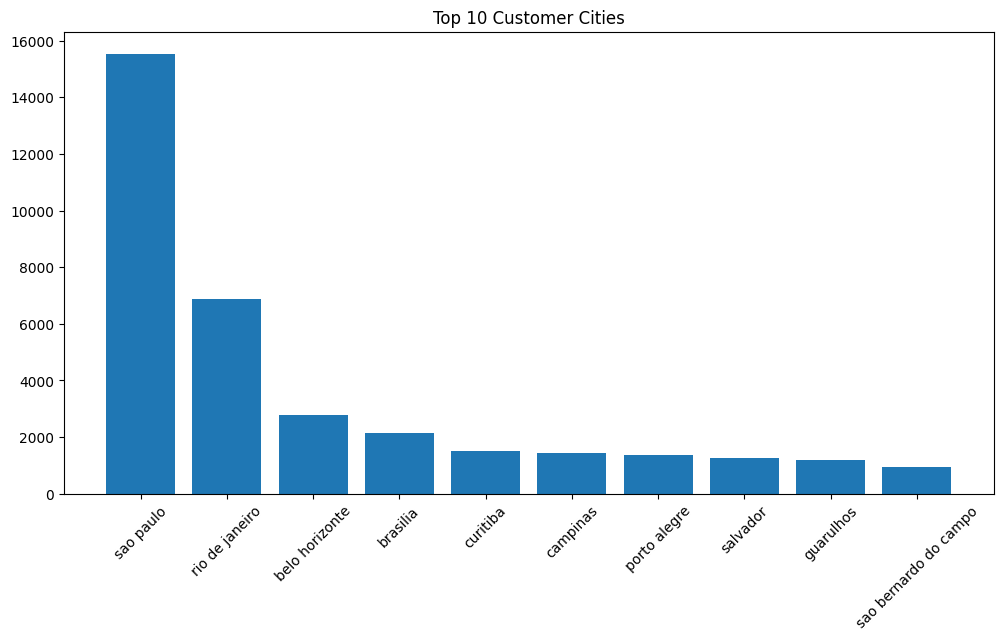

In [11]:
# City Chart

plt.figure(figsize=(12,6))

plt.bar(
    top_cities['customer_city'],
    top_cities['total_customers']
)

plt.xticks(rotation=45)

plt.title("Top 10 Customer Cities")
plt.show()

In [12]:
# Repeat customers

query = """
SELECT c.customer_unique_id,
       COUNT(o.order_id) AS total_orders
FROM customers c
JOIN orders o
ON c.customer_id = o.customer_id
GROUP BY c.customer_unique_id
HAVING COUNT(o.order_id) > 1
ORDER BY total_orders DESC;
"""

repeat_customers = pd.read_sql(query, engine)

repeat_customers.head()

,customer_unique_id,total_orders
0,8d50f5eadf50201ccdcedfb9e2ac8455,17
1,3e43e6105506432c953e165fb2acf44c,9
2,ca77025e7201e3b30c44b472ff346268,7
3,6469f99c1f9dfae7733b25662e7f1782,7
4,1b6c7548a2a1f9037c1fd3ddfed95f33,7


In [14]:
# Repeat customers by KPI 

repeat_count = len(repeat_customers)

print("Repeat Customers:", repeat_count)

Repeat Customers: 2997


In [15]:
# Top Spending Customers

query = """
SELECT c.customer_unique_id,
       ROUND(SUM(p.payment_value),2) AS total_spent
FROM customers c
JOIN orders o
ON c.customer_id=o.customer_id
JOIN payments p
ON o.order_id=p.order_id
GROUP BY c.customer_unique_id
ORDER BY total_spent DESC
LIMIT 20;
"""

top_spenders = pd.read_sql(query, engine)

top_spenders.head()

,customer_unique_id,total_spent
0,0a0a92112bd4c708ca5fde585afaa872,13664.08
1,46450c74a0d8c5ca9395da1daac6c120,9553.02
2,da122df9eeddfedc1dc1f5349a1a690c,7571.63
3,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
4,dc4802a71eae9be1dd28f5d788ceb526,6929.31


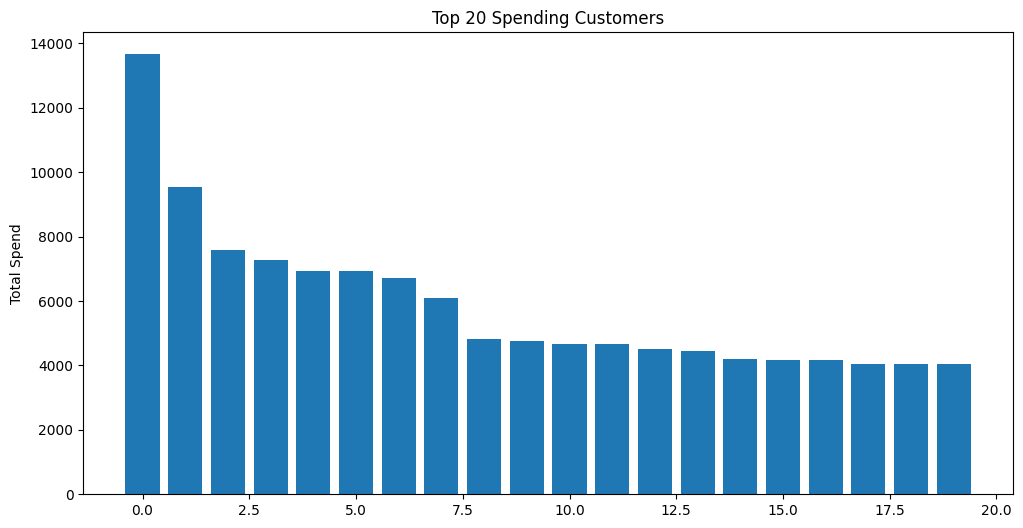

In [16]:
# Top Spenders Charts

plt.figure(figsize=(12,6))

plt.bar(
    range(len(top_spenders)),
    top_spenders['total_spent']
)

plt.title("Top 20 Spending Customers")
plt.ylabel("Total Spend")

plt.show()